In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

df = pd.read_csv("all_stocks_5yr.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["Name", "date"])

df["daily_range"] = df["high"] - df["low"]
df["daily_return"] = (df["close"] - df["open"]) / df["open"] * 100

print(df.head())
print(df.info())

            date   open   high    low  close   volume Name  daily_range  \
71611 2013-02-08  45.07  45.35  45.00  45.08  1824755    A         0.35   
71612 2013-02-11  45.17  45.18  44.45  44.60  2915405    A         0.73   
71613 2013-02-12  44.81  44.95  44.50  44.62  2373731    A         0.45   
71614 2013-02-13  44.81  45.24  44.68  44.75  2052338    A         0.56   
71615 2013-02-14  44.72  44.78  44.36  44.58  3826245    A         0.42   

       daily_return  
71611      0.022188  
71612     -1.261899  
71613     -0.424012  
71614     -0.133899  
71615     -0.313059  
<class 'pandas.DataFrame'>
Index: 619040 entries, 71611 to 619039
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date          619040 non-null  datetime64[us]
 1   open          619029 non-null  float64       
 2   high          619032 non-null  float64       
 3   low           619032 non-null  float64       
 4   close   

How Major Stocks Change Over Time

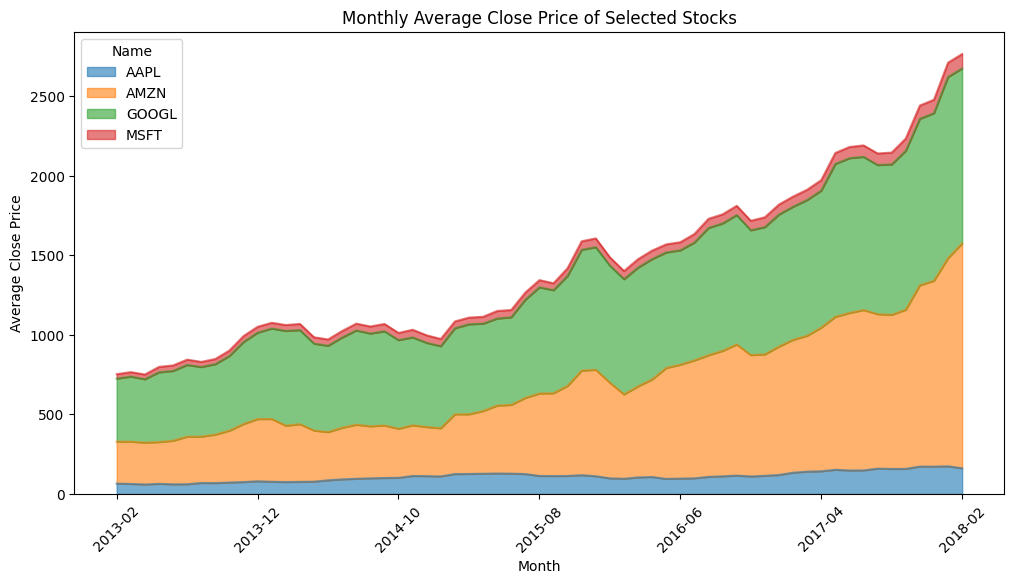

In [20]:
stocks_area = ["AAPL", "MSFT", "GOOGL", "AMZN"]

area_df = df[df["Name"].isin(stocks_area)].copy()
area_df["month"] = area_df["date"].dt.to_period("M")

monthly_close = (
    area_df.groupby(["month", "Name"])["close"]
    .mean()
    .unstack()
)

monthly_close.index = monthly_close.index.astype(str)

monthly_close.plot(kind="area", alpha=0.6, figsize=(12, 6))
plt.title("Monthly Average Close Price of Selected Stocks")
plt.xlabel("Month")
plt.ylabel("Average Close Price")
plt.xticks(rotation=45)
plt.show()

Relationship Between Volume and Price

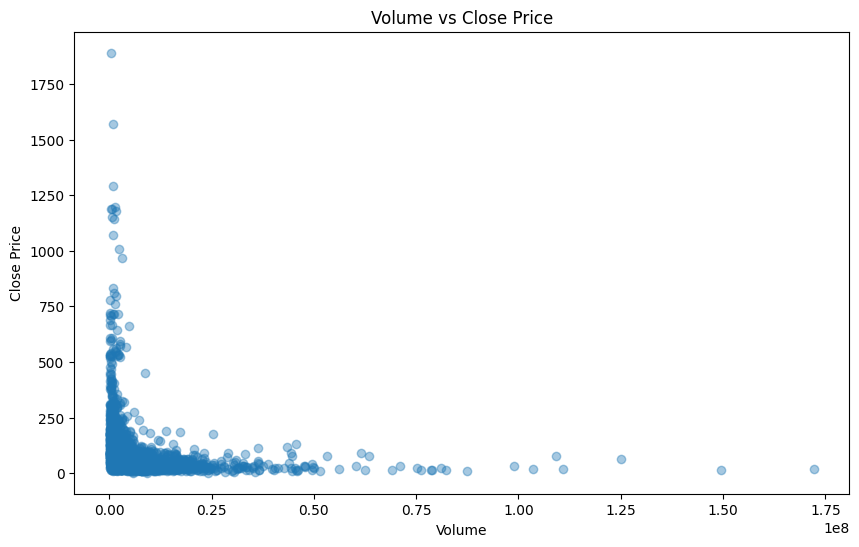

In [21]:
sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample_df["volume"], sample_df["close"], alpha=0.4)
plt.title("Volume vs Close Price")
plt.xlabel("Volume")
plt.ylabel("Close Price")
plt.show()

When the Scatter Plot Gets Too Dense

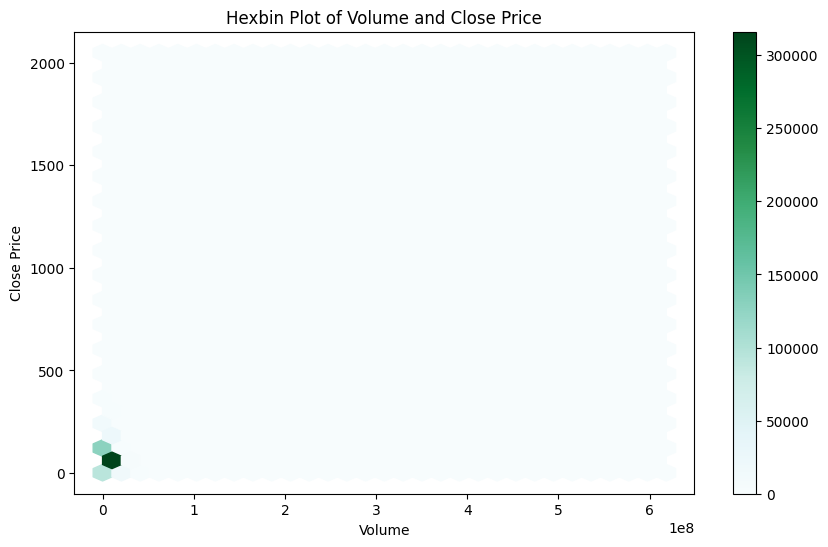

In [22]:
df.plot.hexbin(x="volume", y="close", gridsize=30, figsize=(10, 6))
plt.title("Hexbin Plot of Volume and Close Price")
plt.xlabel("Volume")
plt.ylabel("Close Price")
plt.show()

Which Stocks Take the Largest Share of Trading Volume

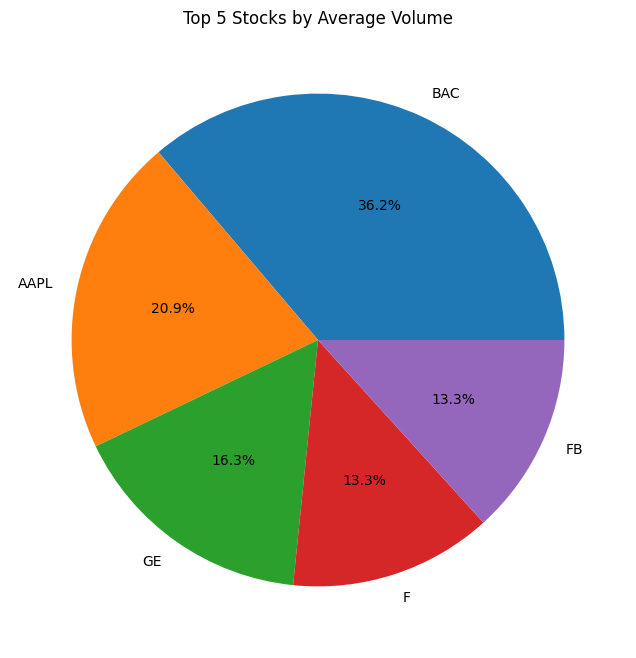

In [23]:
top5_volume = (
    df.groupby("Name")["volume"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

top5_volume.plot(kind="pie", autopct="%1.1f%%", figsize=(8, 8))
plt.title("Top 5 Stocks by Average Volume")
plt.ylabel("")
plt.show()

How the Numerical Variables Relate

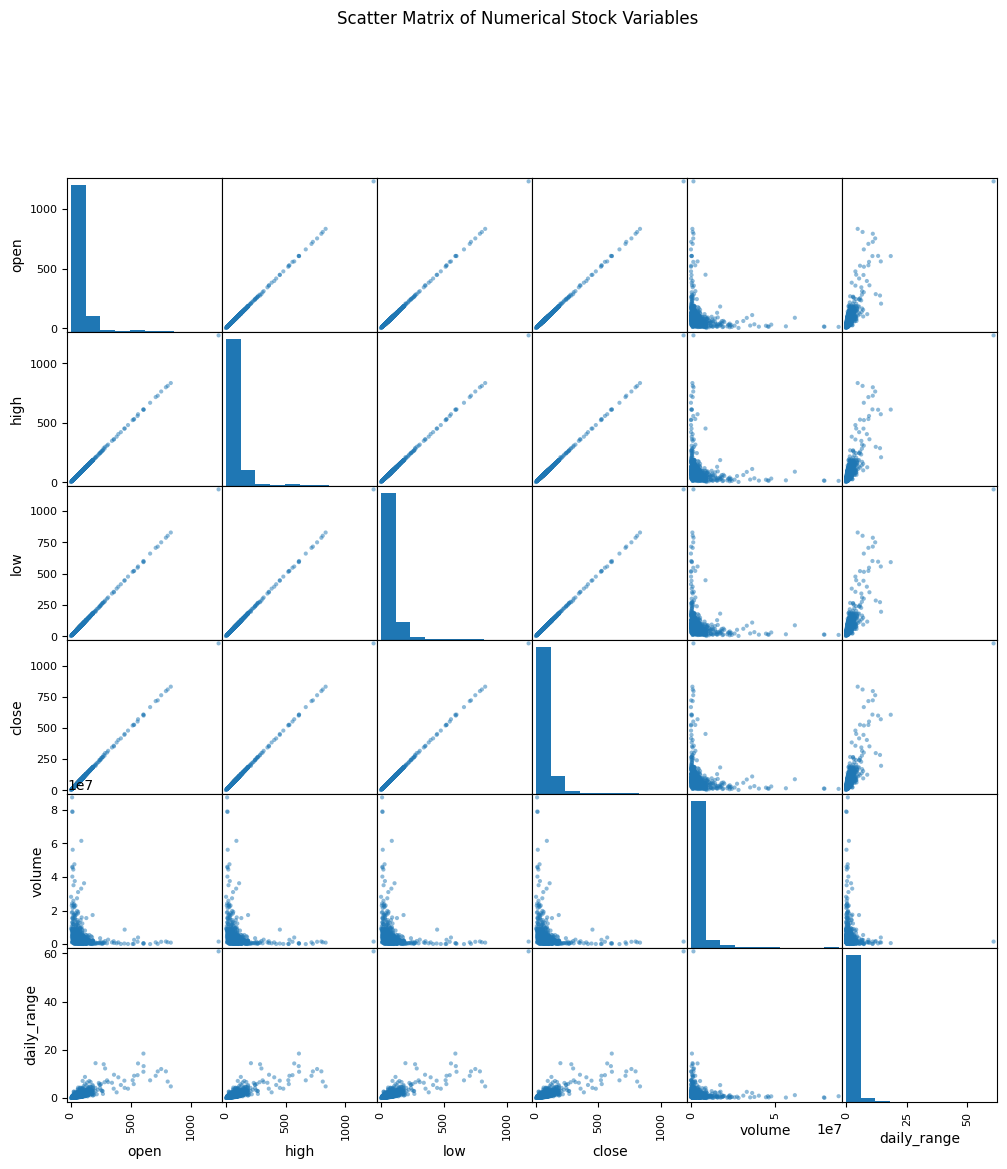

In [24]:
matrix_df = df[["open", "high", "low", "close", "volume", "daily_range"]].sample(1000, random_state=42)

scatter_matrix(matrix_df, figsize=(12, 12), diagonal="hist")
plt.suptitle("Scatter Matrix of Numerical Stock Variables", y=1.02)
plt.show()

Highest Average Close Price

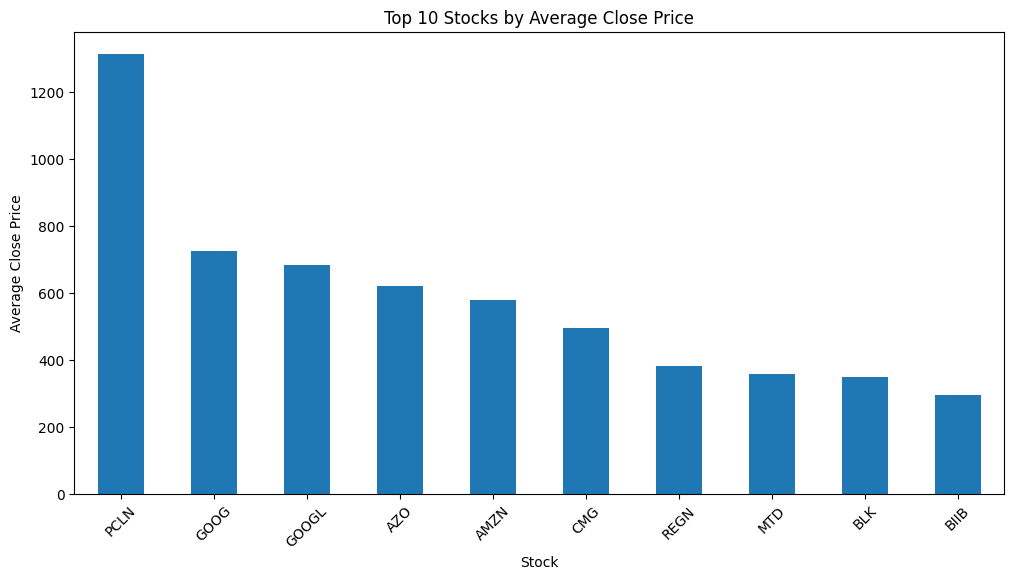

In [25]:
summary = df.groupby("Name").agg(
    avg_open=("open", "mean"),
    avg_close=("close", "mean"),
    avg_volume=("volume", "mean"),
    avg_range=("daily_range", "mean"),
    avg_return=("daily_return", "mean")
).sort_values("avg_close", ascending=False)

top10_close = summary["avg_close"].head(10)

top10_close.plot(kind="bar", figsize=(12, 6))
plt.title("Top 10 Stocks by Average Close Price")
plt.xlabel("Stock")
plt.ylabel("Average Close Price")
plt.xticks(rotation=45)
plt.show()

Individual Stock Prices Movement

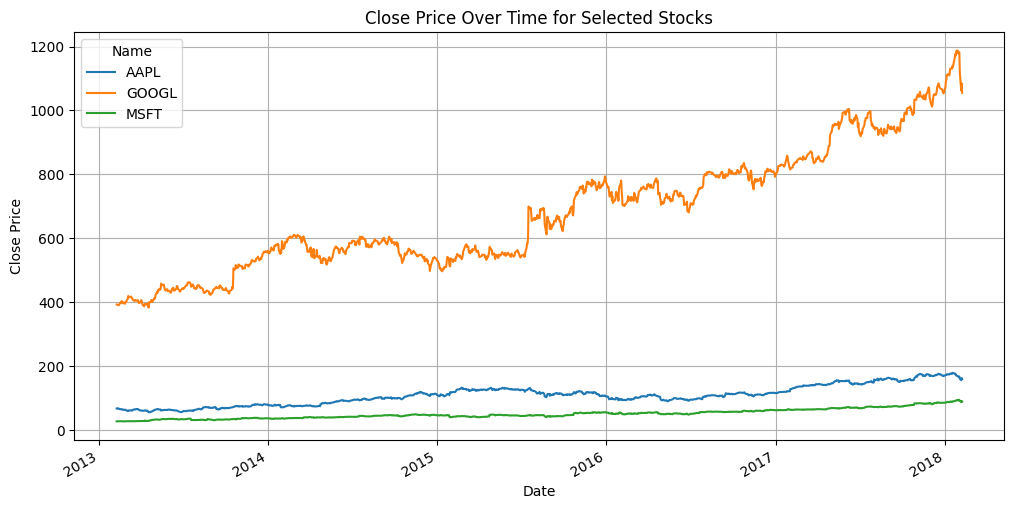

In [26]:
stocks_line = ["AAPL", "MSFT", "GOOGL"]

line_df = df[df["Name"].isin(stocks_line)]
pivot_close = line_df.pivot(index="date", columns="Name", values="close")

pivot_close.plot(figsize=(12, 6))
plt.title("Close Price Over Time for Selected Stocks")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()

Distribution of Close Prices

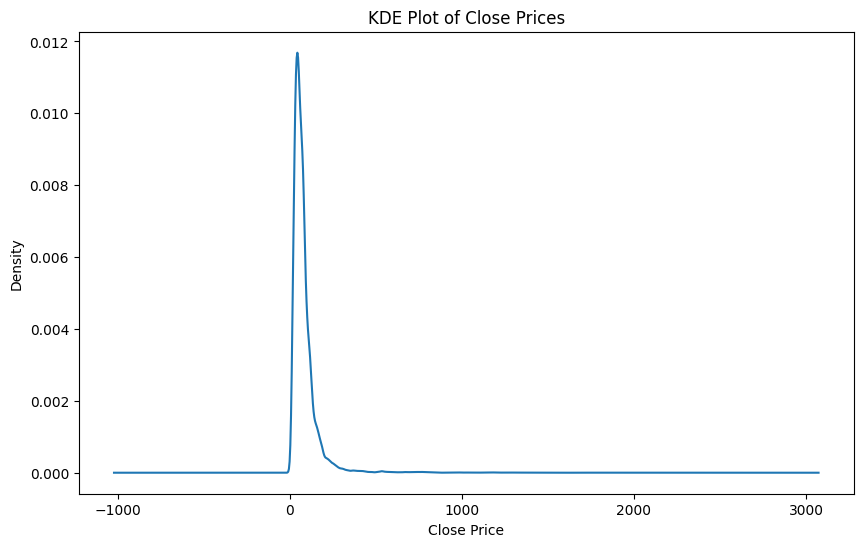

In [27]:
plt.figure(figsize=(10, 6))
df["close"].plot(kind="kde")
plt.title("KDE Plot of Close Prices")
plt.xlabel("Close Price")
plt.show()

Different Stocks Have Different Price Distributions

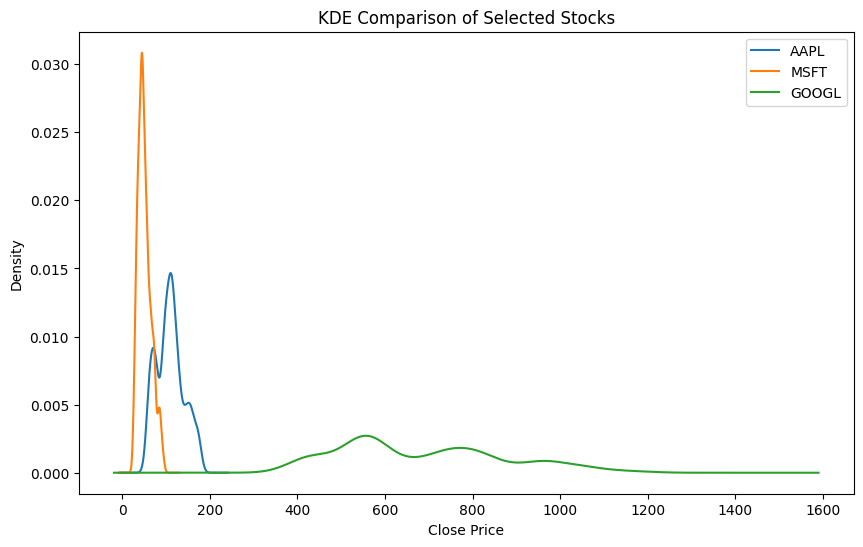

In [28]:
stocks_kde = ["AAPL", "MSFT", "GOOGL"]

plt.figure(figsize=(10, 6))
for stock in stocks_kde:
    df[df["Name"] == stock]["close"].plot(kind="kde", label=stock)

plt.title("KDE Comparison of Selected Stocks")
plt.xlabel("Close Price")
plt.legend()
plt.show()